In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
from pathlib import Path

In [2]:
data_dir = Path('../Data')
results_dir = Path('../Results')

In [3]:
futures = pd.read_csv(data_dir / 'futures_prices.csv')
shape_factors = pd.read_csv(data_dir / 'shape_factors.csv')
data_dictionary = pd.read_csv(data_dir / 'data_dictionary.csv')
sources = pd.read_csv(data_dir / 'sources.csv')

day_ahead_prices = pd.read_csv(data_dir / 'day_ahead_prices.csv')

## Hourly Price Forward Curve (HPFC)

**Inputs:** `futures_prices.csv` and `shape_factors.csv` 

In [4]:
market_activity_threshold = 100
granular_periods = ['M01', 'M02', 'M03', 'Q2', 'Q3', 'Q4']

In [5]:
display(data_dictionary[data_dictionary['file'].isin(['futures_prices.csv', 'shape_factors.csv'])].reset_index(drop=True))
display(sources[sources['dataset'].isin(['Day-Ahead price and historical shape inputs', 'Teaching futures snapshot'])].reset_index(drop=True))

,file,column,description,data_status
0,futures_prices.csv,quote_date,Date of the teaching futures snapshot.,synthetic
1,futures_prices.csv,delivery_year,Calendar year in which the product delivers.,synthetic
2,futures_prices.csv,load_type,BASE delivers in all intervals; PEAK only in t...,synthetic
3,futures_prices.csv,product_type,"YEAR, QUARTER, or MONTH delivery product.",synthetic
4,futures_prices.csv,delivery_period,"Product delivery label such as CAL, Q1, or M01.",synthetic
5,futures_prices.csv,delivery_start,Inclusive delivery-period start date.,synthetic
6,futures_prices.csv,delivery_end_exclusive,Exclusive delivery-period end date.,synthetic
7,futures_prices.csv,price_eur_mwh,Teaching forward price in EUR/MWh.,synthetic
8,futures_prices.csv,market_activity,Teaching tradability indicator; higher values ...,synthetic
9,shape_factors.csv,timestamp_utc,Quarter-hour start in UTC; primary join key.,derived


,dataset,publisher,status,url
0,Day-Ahead price and historical shape inputs,Bundesnetzagentur | SMARD.de,observed,https://www.smard.de/app/chart_data/4169/DE/in...
1,Teaching futures snapshot,HTW Summer School project,synthetic,NaN


In [6]:
futures_data = futures.copy()
for column in ['quote_date', 'delivery_start', 'delivery_end_exclusive']:
    futures_data[column] = pd.to_datetime(futures_data[column])

shape_data = shape_factors.copy()
provided_local_as_utc = pd.to_datetime(shape_data['timestamp_local'], utc=True)
shape_data['timestamp_utc'] = pd.to_datetime(shape_data['timestamp_utc'], utc=True)
shape_data['timestamp_local'] = shape_data['timestamp_utc'].dt.tz_convert('Europe/Berlin')
shape_data['local_date'] = shape_data['timestamp_local'].dt.tz_localize(None).dt.normalize()
shape_data['local_peak_check'] = shape_data['timestamp_local'].dt.weekday.lt(5) & shape_data['timestamp_local'].dt.hour.ge(8) & shape_data['timestamp_local'].dt.hour.lt(20)
local_day_counts = shape_data.groupby(shape_data['timestamp_local'].dt.date).size()
utc_steps = shape_data['timestamp_utc'].sort_values().diff().dropna()

quality_checks = pd.DataFrame([
    {'Check': '35,136 unique quarter-hours', 'Observed': f"{len(shape_data):,} rows / {shape_data['timestamp_utc'].nunique():,} UTC keys", 'Passed': len(shape_data) == 35136 and shape_data['timestamp_utc'].is_unique},
    {'Check': 'UTC grid is ordered and gapless at 15 minutes', 'Observed': f"{utc_steps.min()} to {utc_steps.max()}", 'Passed': shape_data['timestamp_utc'].is_monotonic_increasing and utc_steps.eq(pd.Timedelta(minutes=15)).all()},
    {'Check': 'Provided local offsets map to the same UTC instants', 'Observed': f"{provided_local_as_utc.ne(shape_data['timestamp_utc']).sum():,} mismatches", 'Passed': provided_local_as_utc.eq(shape_data['timestamp_utc']).all()},
    {'Check': 'Berlin Peak flag is Monday-Friday 08:00-20:00', 'Observed': f"{shape_data['is_peak'].ne(shape_data['local_peak_check'].astype(int)).sum():,} mismatches", 'Passed': shape_data['is_peak'].eq(shape_data['local_peak_check'].astype(int)).all()},
    {'Check': 'DST-aware local days contain 92, 96, or 100 intervals', 'Observed': str(sorted(local_day_counts.unique())), 'Passed': set(local_day_counts.unique()) == {92, 96, 100}},
    {'Check': 'Shape factors are complete, positive, and annual-mean one', 'Observed': f"missing={shape_data['historical_shape_factor'].isna().sum()}, min={shape_data['historical_shape_factor'].min():.6f}, mean={shape_data['historical_shape_factor'].mean():.9f}", 'Passed': shape_data['historical_shape_factor'].notna().all() and shape_data['historical_shape_factor'].gt(0).all() and np.isclose(shape_data['historical_shape_factor'].mean(), 1)},
    {'Check': 'Every delivery period has one Base and one Peak quote', 'Observed': f"duplicates={futures_data.duplicated(['delivery_period', 'load_type']).sum()}, periods={futures_data['delivery_period'].nunique()}", 'Passed': futures_data.duplicated(['delivery_period', 'load_type']).sum() == 0 and futures_data.groupby('delivery_period')['load_type'].nunique().eq(2).all()},
    {'Check': 'Quotes are available before 2024 delivery', 'Observed': ', '.join(futures_data['quote_date'].dt.strftime('%Y-%m-%d').unique()), 'Passed': futures_data['quote_date'].max() < futures_data['delivery_start'].min()}
])
display(quality_checks)
assert quality_checks['Passed'].all(), quality_checks.loc[~quality_checks['Passed']].to_dict('records')

,Check,Observed,Passed
0,"35,136 unique quarter-hours","35,136 rows / 35,136 UTC keys",True
1,UTC grid is ordered and gapless at 15 minutes,0 days 00:15:00 to 0 days 00:15:00,True
2,Provided local offsets map to the same UTC ins...,0 mismatches,True
3,Berlin Peak flag is Monday-Friday 08:00-20:00,0 mismatches,True
4,"DST-aware local days contain 92, 96, or 100 in...","[np.int64(92), np.int64(96), np.int64(100)]",True
5,"Shape factors are complete, positive, and annu...","missing=0, min=0.122131, mean=1.000000000",True
6,Every delivery period has one Base and one Pea...,"duplicates=0, periods=17",True
7,Quotes are available before 2024 delivery,2023-09-29,True


For each selected delivery block, infer the Off-Peak price from the quoted Base and Peak averages:

$$F^{OFF}_b = \frac{N_b F^{BASE}_b - N^{PEAK}_b F^{PEAK}_b}{N^{OFF}_b}$$

Then scale prices by the historical factor, normalized separately within each block and Peak/Off-Peak slice:

$$HPFC_t = F^{slice}_b \frac{s_t}{\overline{s}_{b,slice}}$$

In [7]:
paired_activity = futures_data.pivot(index='delivery_period', columns='load_type', values='market_activity')
eligible_periods = paired_activity.index[paired_activity[['BASE', 'PEAK']].min(axis=1).ge(market_activity_threshold)].tolist()

def build_hpfc(periods, shape_source):
    assert set(periods).issubset(eligible_periods)

    anchor_quotes = futures_data[futures_data['delivery_period'].isin(periods)].copy()
    anchor_quotes['delivery_period'] = pd.Categorical(anchor_quotes['delivery_period'], categories=periods, ordered=True)
    anchor_quotes = anchor_quotes.sort_values(['delivery_period', 'load_type']).reset_index(drop=True)
    base_anchors = anchor_quotes[anchor_quotes['load_type'].eq('BASE')].sort_values('delivery_start').reset_index(drop=True)
    coverage_is_continuous = base_anchors['delivery_start'].iloc[0] == pd.Timestamp('2024-01-01') and base_anchors['delivery_end_exclusive'].iloc[-1] == pd.Timestamp('2025-01-01') and base_anchors['delivery_start'].iloc[1:].reset_index(drop=True).equals(base_anchors['delivery_end_exclusive'].iloc[:-1].reset_index(drop=True))
    assert coverage_is_continuous

    anchor_table = anchor_quotes.pivot(index='delivery_period', columns='load_type', values=['price_eur_mwh', 'market_activity']).reindex(periods)

    shape_local = shape_source.copy()
    shape_local['optimization_block'] = pd.Series(pd.NA, index=shape_local.index, dtype='string')
    shape_local['assignment_count'] = 0
    for anchor in base_anchors.itertuples():
        period_mask = shape_local['local_date'].ge(anchor.delivery_start) & shape_local['local_date'].lt(anchor.delivery_end_exclusive)
        shape_local.loc[period_mask, 'optimization_block'] = str(anchor.delivery_period)
        shape_local.loc[period_mask, 'assignment_count'] += 1
    assert shape_local['assignment_count'].eq(1).all()

    quotes = anchor_quotes.pivot(index='delivery_period', columns='load_type', values='price_eur_mwh').reindex(periods)
    block_inputs = shape_local.groupby('optimization_block', sort=False).agg(n_all=('is_peak', 'size'), n_peak=('is_peak', 'sum')).reindex(periods)
    block_inputs['n_off'] = block_inputs['n_all'] - block_inputs['n_peak']
    block_inputs = block_inputs.join(quotes.rename(columns={'BASE': 'base_quote_eur_mwh', 'PEAK': 'peak_quote_eur_mwh'}))
    block_inputs['off_peak_quote_eur_mwh'] = (block_inputs['base_quote_eur_mwh'] * block_inputs['n_all'] - block_inputs['peak_quote_eur_mwh'] * block_inputs['n_peak']) / block_inputs['n_off']

    shape_local['base_quote_eur_mwh'] = shape_local['optimization_block'].map(block_inputs['base_quote_eur_mwh']).astype(float)
    shape_local['peak_quote_eur_mwh'] = shape_local['optimization_block'].map(block_inputs['peak_quote_eur_mwh']).astype(float)
    shape_local['off_peak_quote_eur_mwh'] = shape_local['optimization_block'].map(block_inputs['off_peak_quote_eur_mwh']).astype(float)
    shape_local['slice'] = np.where(shape_local['is_peak'].eq(1), 'PEAK', 'OFF_PEAK')
    shape_local['slice_price_eur_mwh'] = np.where(shape_local['is_peak'].eq(1), shape_local['peak_quote_eur_mwh'], shape_local['off_peak_quote_eur_mwh'])
    shape_local['slice_shape_mean'] = shape_local.groupby(['optimization_block', 'is_peak'], sort=False)['historical_shape_factor'].transform('mean')
    shape_local['normalized_shape_factor'] = shape_local['historical_shape_factor'] / shape_local['slice_shape_mean']
    shape_local['hpfc_eur_mwh'] = shape_local['slice_price_eur_mwh'] * shape_local['normalized_shape_factor']

    hpfc_out = shape_local[['timestamp_utc', 'timestamp_local', 'month', 'hour', 'weekday', 'is_peak', 'optimization_block', 'slice', 'historical_shape_factor', 'slice_shape_mean', 'normalized_shape_factor', 'slice_price_eur_mwh', 'hpfc_eur_mwh']].copy()
    assert len(hpfc_out) == 35136 and np.isfinite(hpfc_out['hpfc_eur_mwh']).all()

    return anchor_table, base_anchors, block_inputs, hpfc_out

In [8]:
def run_calibration(hpfc_curve, block_inputs, periods):
    calibration = hpfc_curve.groupby('optimization_block', sort=False).agg(N_All=('is_peak', 'size'), N_Peak=('is_peak', 'sum'), HPFC_Base_Mean=('hpfc_eur_mwh', 'mean')).reindex(periods)
    calibration['N_Off_Peak'] = calibration['N_All'] - calibration['N_Peak']
    calibration['Base_Quote'] = block_inputs['base_quote_eur_mwh']
    calibration['Peak_Quote'] = block_inputs['peak_quote_eur_mwh']
    calibration['Implied_Off_Peak'] = block_inputs['off_peak_quote_eur_mwh']
    calibration['HPFC_Peak_Mean'] = hpfc_curve[hpfc_curve['is_peak'].eq(1)].groupby('optimization_block')['hpfc_eur_mwh'].mean()
    calibration['HPFC_Off_Peak_Mean'] = hpfc_curve[hpfc_curve['is_peak'].eq(0)].groupby('optimization_block')['hpfc_eur_mwh'].mean()
    calibration['Base_Error'] = calibration['HPFC_Base_Mean'] - calibration['Base_Quote']
    calibration['Peak_Error'] = calibration['HPFC_Peak_Mean'] - calibration['Peak_Quote']
    calibration['Off_Peak_Error'] = calibration['HPFC_Off_Peak_Mean'] - calibration['Implied_Off_Peak']
    calibration['Value_Error_EUR_per_MW'] = hpfc_curve.groupby('optimization_block')['hpfc_eur_mwh'].sum() * 0.25 - calibration['N_All'] * calibration['Base_Quote'] * 0.25

    price_errors = calibration[['Base_Error', 'Peak_Error', 'Off_Peak_Error']].abs().to_numpy()
    assert price_errors.max() < 1e-10
    assert calibration['Value_Error_EUR_per_MW'].abs().max() < 1e-6
    return calibration, price_errors

In [9]:
def run_independent_check(hpfc_curve, check_periods):
    rows = []
    for period in check_periods:
        period_quotes = futures_data[futures_data['delivery_period'].eq(period)].set_index('load_type')
        period_start = period_quotes['delivery_start'].iloc[0]
        period_end = period_quotes['delivery_end_exclusive'].iloc[0]
        period_mask = shape_data['local_date'].ge(period_start) & shape_data['local_date'].lt(period_end)
        rows.append({'Period': period, 'HPFC Base Mean': hpfc_curve.loc[period_mask, 'hpfc_eur_mwh'].mean(), 'Base Quote': period_quotes.loc['BASE', 'price_eur_mwh'], 'HPFC Peak Mean': hpfc_curve.loc[period_mask & hpfc_curve['is_peak'].eq(1), 'hpfc_eur_mwh'].mean(), 'Peak Quote': period_quotes.loc['PEAK', 'price_eur_mwh']})
    checks = pd.DataFrame(rows)
    if len(checks):
        checks['Base Difference'] = checks['HPFC Base Mean'] - checks['Base Quote']
        checks['Peak Difference'] = checks['HPFC Peak Mean'] - checks['Peak Quote']
        # assert checks[['Base Difference', 'Peak Difference']].abs().to_numpy().max() < 0.01
    return checks

In [10]:
def run_hourly(hpfc_curve):
    hourly_check = hpfc_curve.assign(timestamp_hour_utc=hpfc_curve['timestamp_utc'].dt.floor('h')).groupby('timestamp_hour_utc').agg(intervals=('hpfc_eur_mwh', 'size'), unique_hpfc=('hpfc_eur_mwh', 'nunique'))
    hpfc_hourly = hpfc_curve.assign(timestamp_hour_utc=hpfc_curve['timestamp_utc'].dt.floor('h')).groupby('timestamp_hour_utc', as_index=False).agg(timestamp_local=('timestamp_local', 'first'), is_peak=('is_peak', 'first'), optimization_block=('optimization_block', 'first'), historical_shape_factor=('historical_shape_factor', 'first'), hpfc_eur_mwh=('hpfc_eur_mwh', 'first'))
    assert len(hpfc_hourly) == 8784 and hourly_check['intervals'].eq(4).all() and hourly_check['unique_hpfc'].eq(1).all()
    return hpfc_hourly

In [11]:
def build_summary(hpfc_curve, hpfc_hourly, price_errors, independent_checks, label):
    ind_max = independent_checks[['Base Difference', 'Peak Difference']].abs().to_numpy().max() if len(independent_checks) else np.nan
    return pd.DataFrame({
        'quarter_hour_rows': [len(hpfc_curve)], 'hourly_rows': [len(hpfc_hourly)], 'missing_hpfc': [hpfc_curve['hpfc_eur_mwh'].isna().sum()],
        'minimum_eur_mwh': [hpfc_curve['hpfc_eur_mwh'].min()], 'annual_mean_eur_mwh': [hpfc_curve['hpfc_eur_mwh'].mean()], 'maximum_eur_mwh': [hpfc_curve['hpfc_eur_mwh'].max()],
        'max_calibration_error_eur_mwh': [price_errors.max()], 'max_independent_difference_eur_mwh': [ind_max]
    }, index=[label])

In [12]:
period_sets = {
    'GRANULAR': granular_periods,             
    'QUARTERLY': ['Q1', 'Q2', 'Q3', 'Q4'],    
    'ANNUAL': ['CAL'],                        
}
all_periods = ['CAL', 'Q1', 'Q2', 'Q3', 'Q4', 'M01', 'M02', 'M03', 'M04', 'M05', 'M06', 'M07', 'M08', 'M09', 'M10', 'M11', 'M12']

results = {}
summaries = []
curves = {}
for label, periods in period_sets.items():
    anchor_table, base_anchors, block_inputs, hpfc_curve = build_hpfc(periods, shape_data)
    calibration, price_errors = run_calibration(hpfc_curve, block_inputs, periods)
    hpfc_hourly = run_hourly(hpfc_curve)
    check_periods = [p for p in all_periods if p not in periods]
    independent_checks = run_independent_check(hpfc_curve, check_periods)
    summary = build_summary(hpfc_curve, hpfc_hourly, price_errors, independent_checks, label)
    summaries.append(summary)
    results[label] = dict(anchor_table=anchor_table, hpfc=hpfc_curve, calibration=calibration, hpfc_hourly=hpfc_hourly, independent_checks=independent_checks)
    curves[label] = hpfc_curve[['timestamp_local', 'hpfc_eur_mwh']]

    print(f'--- {label} ---')
    display(results[label]['anchor_table'])
    display(results[label]['calibration'].reset_index().round(6))
    if len(independent_checks):
        display(independent_checks.round(6))

for label, curve in curves.items():
    curve.to_csv(results_dir / f'{label}_hpfc_curve.csv', index=False)

--- GRANULAR ---


price_eur_mwh         market_activity       
load_type                BASE    PEAK            BASE   PEAK
delivery_period                                             
M01                     75.32   88.68           900.0  252.0
M02                     60.09   70.59           800.0  224.0
M03                     63.45   72.79           650.0  182.0
Q2                      66.23   64.76          2200.0  616.0
Q3                      74.74   69.07          1600.0  448.0
Q4                     101.39  134.42          1400.0  392.0

,optimization_block,N_All,N_Peak,HPFC_Base_Mean,N_Off_Peak,Base_Quote,Peak_Quote,Implied_Off_Peak,HPFC_Peak_Mean,HPFC_Off_Peak_Mean,Base_Error,Peak_Error,Off_Peak_Error,Value_Error_EUR_per_MW
0,M01,2976,1104,75.32,1872,75.32,88.68,67.441026,88.68,67.441026,0.0,0.0,0.0,0.0
1,M02,2784,1008,60.09,1776,60.09,70.59,54.130541,70.59,54.130541,-0.0,0.0,0.0,0.0
2,M03,2972,1008,63.45,1964,63.45,72.79,58.656354,72.79,58.656354,-0.0,0.0,0.0,0.0
3,Q2,8736,3120,66.23,5616,66.23,64.76,67.046667,64.76,67.046667,0.0,0.0,-0.0,0.0
4,Q3,8832,3168,74.74,5664,74.74,69.07,77.911356,69.07,77.911356,0.0,0.0,-0.0,0.0
5,Q4,8836,3168,101.39,5668,101.39,134.42,82.928631,134.42,82.928631,0.0,0.0,0.0,0.0


,Period,HPFC Base Mean,Base Quote,HPFC Peak Mean,Peak Quote,Base Difference,Peak Difference
0,CAL,77.259429,77.26,86.604427,86.60,-0.000571,0.004427
1,Q1,66.424219,66.42,77.701846,77.70,0.004219,0.001846
2,M04,62.107518,67.11,59.183215,72.56,-5.002482,-13.376785
3,M05,60.633738,60.96,59.438771,52.40,-0.326262,7.038771
4,M06,76.135286,79.64,77.013876,80.57,-3.504714,-3.556124
5,M07,64.759167,59.45,54.726003,49.47,5.309167,5.256003
6,M08,70.082409,84.80,66.378682,74.16,-14.717591,-7.781318
7,M09,89.866371,73.06,87.599568,76.62,16.806371,10.979568
8,M10,93.361789,91.85,109.439117,111.59,1.511789,-2.150883
9,M11,114.477323,106.66,166.702728,140.84,7.817323,25.862728


--- QUARTERLY ---


...

,Period,HPFC Base Mean,Base Quote,HPFC Peak Mean,Peak Quote,Base Difference,Peak Difference
0,CAL,77.258380,77.26,86.603969,86.60,-0.001620,0.003969
1,M01,75.825653,75.32,87.625388,88.68,0.505653,-1.054612
2,M02,64.892146,60.09,75.510992,70.59,4.802146,4.920992
3,M03,58.432894,63.45,69.018345,72.79,-5.017106,-3.771655
4,M04,62.107518,67.11,59.183215,72.56,-5.002482,-13.376785
5,M05,60.633738,60.96,59.438771,52.40,-0.326262,7.038771
6,M06,76.135286,79.64,77.013876,80.57,-3.504714,-3.556124
7,M07,64.759167,59.45,54.726003,49.47,5.309167,5.256003
8,M08,70.082409,84.80,66.378682,74.16,-14.717591,-7.781318
9,M09,89.866371,73.06,87.599568,76.62,16.806371,10.979568


--- ANNUAL ---


price_eur_mwh       market_activity        
load_type                BASE  PEAK            BASE    PEAK
delivery_period                                            
CAL                     77.26  86.6          5000.0  1400.0

,optimization_block,N_All,N_Peak,HPFC_Base_Mean,N_Off_Peak,Base_Quote,Peak_Quote,Implied_Off_Peak,HPFC_Peak_Mean,HPFC_Off_Peak_Mean,Base_Error,Peak_Error,Off_Peak_Error,Value_Error_EUR_per_MW
0,CAL,35136,12576,77.26,22560,77.26,86.6,72.053447,86.6,72.053447,0.0,0.0,0.0,0.0


,Period,HPFC Base Mean,Base Quote,HPFC Peak Mean,Peak Quote,Base Difference,Peak Difference
0,Q1,69.122371,66.42,76.528200,77.70,2.702371,-1.171800
1,Q2,68.670184,66.23,72.251689,64.76,2.440184,7.491689
2,Q3,86.810377,74.74,96.309377,69.07,12.070377,27.239377
3,Q4,84.248397,101.39,100.940733,134.42,-17.141603,-33.479267
4,M01,78.832896,75.32,86.303902,88.68,3.512896,-2.376098
5,M02,67.511649,60.09,74.372204,70.59,7.421649,3.782204
6,M03,60.907610,63.45,67.977474,72.79,-2.542390,-4.812526
7,M04,64.397215,67.11,66.029760,72.56,-2.712785,-6.530240
8,M05,62.973808,60.96,66.314879,52.40,2.013808,13.914879
9,M06,78.829407,79.64,85.923142,80.57,-0.810593,5.353142


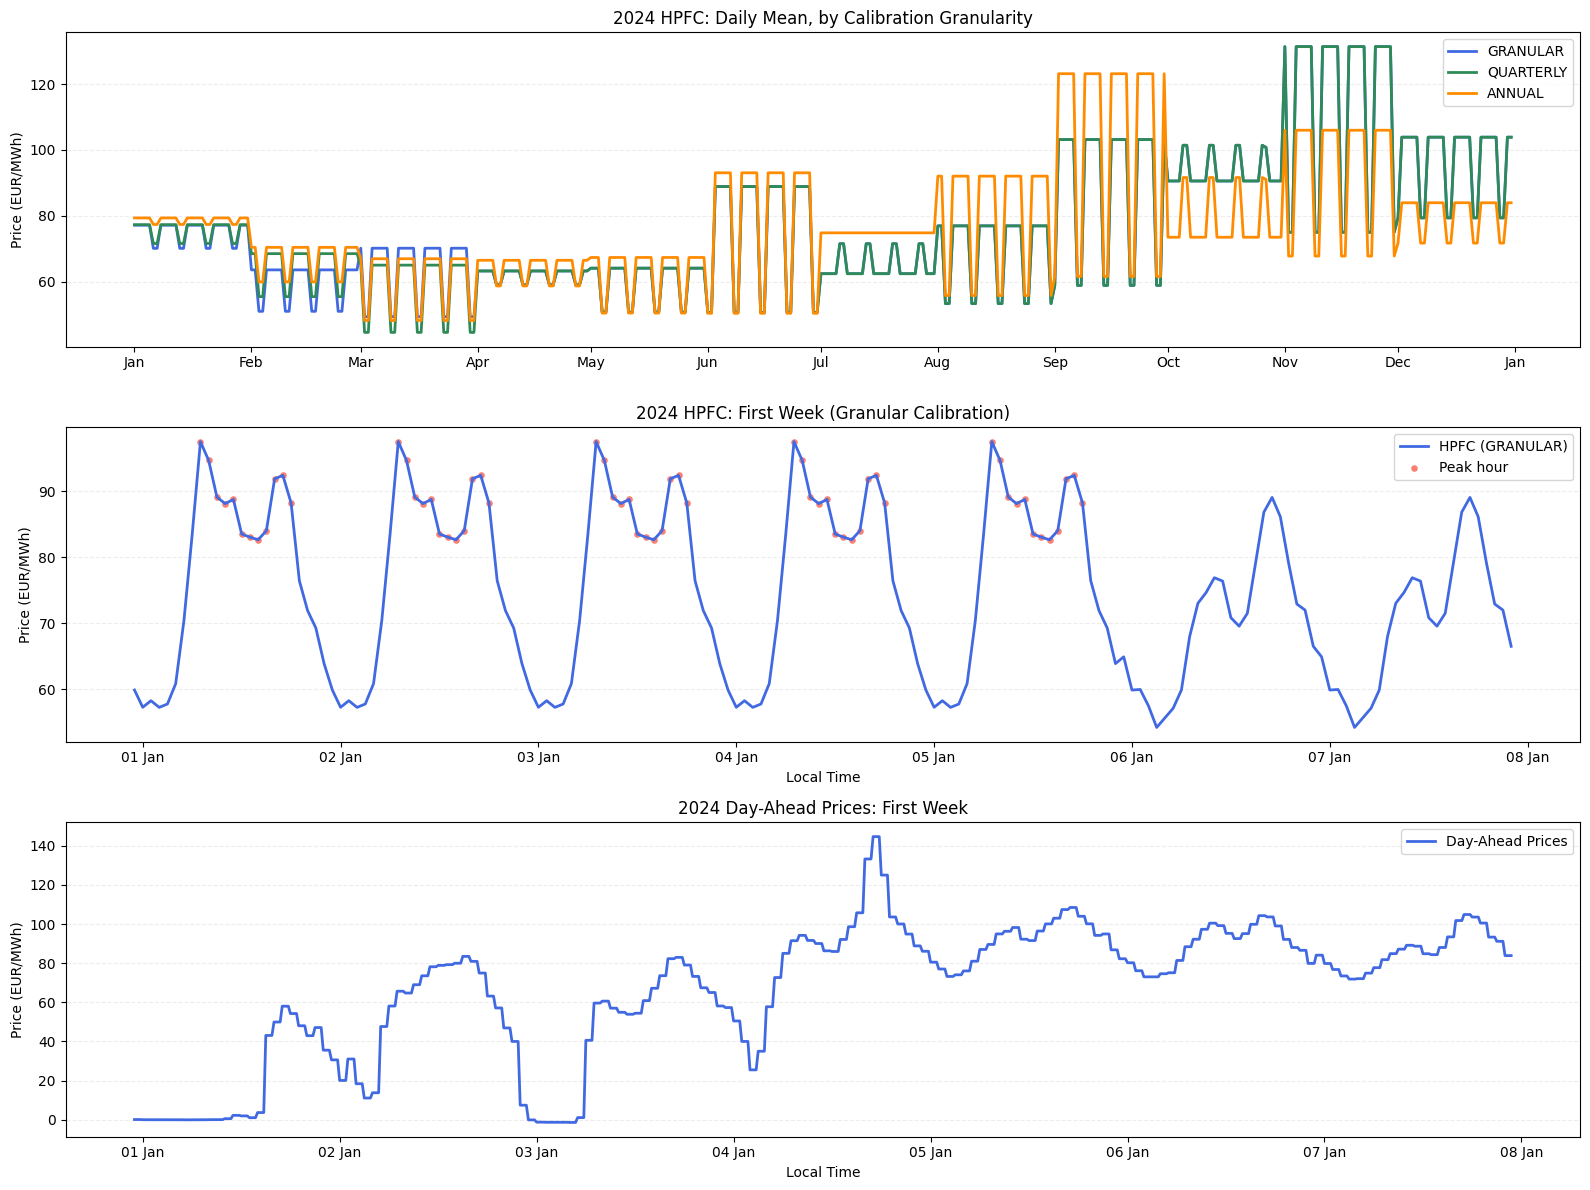

In [13]:

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

colors = {'GRANULAR': 'royalblue', 'QUARTERLY': 'seagreen', 'ANNUAL': 'darkorange'}   
for label, res in results.items():                                                     
    daily = res['hpfc_hourly'].assign(local_date=res['hpfc_hourly']['timestamp_local'].dt.date).groupby('local_date', as_index=False)['hpfc_eur_mwh'].mean()
    daily['local_date'] = pd.to_datetime(daily['local_date'])
    axes[0].plot(daily['local_date'], daily['hpfc_eur_mwh'], color=colors[label], linewidth=2, label=label)

axes[0].set_title('2024 HPFC: Daily Mean, by Calibration Granularity')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0].grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
axes[0].legend()

first_week = results['GRANULAR']['hpfc_hourly']
first_week = first_week[first_week['timestamp_local'].lt(pd.Timestamp('2024-01-08', tz='Europe/Berlin'))]
axes[1].plot(first_week['timestamp_local'], first_week['hpfc_eur_mwh'], color='royalblue', linewidth=2, label='HPFC (GRANULAR)')
axes[1].scatter(first_week.loc[first_week['is_peak'].eq(1), 'timestamp_local'], first_week.loc[first_week['is_peak'].eq(1), 'hpfc_eur_mwh'], color='salmon', s=14, label='Peak hour')
axes[1].set_title('2024 HPFC: First Week (Granular Calibration)')
axes[1].set_xlabel('Local Time')
axes[1].set_ylabel('Price (EUR/MWh)')
axes[1].xaxis.set_major_locator(mdates.DayLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
axes[1].legend()

first_week_prices = day_ahead_prices[shape_data['timestamp_local'].lt(pd.Timestamp('2024-01-08', tz='Europe/Berlin'))]
first_week_prices['timestamp_local'] = pd.to_datetime(first_week_prices['timestamp_local'])

axes[2].plot(first_week_prices['timestamp_local'], first_week_prices['day_ahead_price_eur_mwh'], color='royalblue', linewidth=2, label='Day-Ahead Prices')
axes[2].set_title('2024 Day-Ahead Prices: First Week')
axes[2].set_xlabel('Local Time')
axes[2].set_ylabel('Price (EUR/MWh)')
axes[2].xaxis.set_major_locator(mdates.DayLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[2].grid(axis='y', linestyle='--', color='lightgray', alpha=0.4)
axes[2].legend()
plt.tight_layout()
plt.show()

### Interpretation

The HPFC curves tend to show consistency with contracts they are derived from, but differ from others. These differences trend higher with more granular contracts and those with delivery periods towards the end of the year. Contracts that are courser than those used to derive the curves have insignificant differences. The curve is not a forecast of realised 2024 Day-Ahead prices or evidence that a hedge will perform well.